In [22]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import os

# set seed
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

curr_dir = os.getcwd() 
print("Current directory:", curr_dir)

Current directory: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM


In [23]:
# Choose your dataset (comment out the one you don't want to use)

# dataset = "processed_emodb_og"

dataset = "processed_emodb_speaker_norm"

if dataset == "processed_emodb_og":
    print("Using original EMODB dataset")

elif dataset == "processed_emodb_speaker_norm":
    print("Using speaker-normalized EMODB dataset")

else:
    raise ValueError("Invalid dataset choice. Please choose either 'processed_emodb_og' or 'processed_emodb_speaker_norm'.")

dataset = os.path.join(curr_dir, dataset)
print("Dataset directory:", dataset)


model_dir = os.path.join(curr_dir, "models")
os.makedirs(model_dir, exist_ok=True)

model_name = f"dcnn_{dataset.split('/')[-1]}.pth"
svm_name = f"svm_{dataset.split('/')[-1]}.joblib"

results_dir = os.path.join(curr_dir, "results")
os.makedirs(results_dir, exist_ok=True)

print (f"Model will be saved as: {os.path.join(model_dir, model_name)}")
print (f"SVM will be saved as: {os.path.join(model_dir, svm_name)}")

Using speaker-normalized EMODB dataset
Dataset directory: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/processed_emodb_speaker_norm
Model will be saved as: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/dcnn_processed_emodb_speaker_norm.pth
SVM will be saved as: /Users/leyanzhi/Repositories/SC4001-Neural-Network-Project/SER_DCNN_DTPM/models/svm_processed_emodb_speaker_norm.joblib


# Train DCNN

Here we are finetuning the DCNN (Alexnet, the one trained on images to classify cats and dogs) with our new audio data, in the format of log Mel-spectrogram.

This is known as transfer learning.

In [24]:
# Transform for image preprocessing
# ToTensor: Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0].
# Resize: Resizes the input image to the given size. Here we resize to (227, 227) which is the input size for AlexNet.
# Normalize: Normalizes a tensor image with mean and standard deviation. The mean and std are calculated from the ImageNet dataset, which is commonly used for pre-trained models.
transform = transforms.Compose([
            transforms.ToTensor(),                          
            transforms.Resize((227, 227), antialias=True),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])
        ])

In [25]:
class MelSegmentDataset(Dataset):
    """Dataset for loading mel-spectrogram segments and their corresponding labels."""
    def __init__(self, x_path, y_path):
        self.X          = np.load(x_path)
        self.y          = np.load(y_path)
        self.transform  = transform

    def __len__(self): 
        return len(self.X)

    def __getitem__(self, idx):
        # 1. Get the 3-channel matrix (of shape (3, 64, 64)) for the given index
        img = self.X[idx].copy() 
        
        # 2. Min-Max Scale each channel independently to [0, 1]
        for c in range(3):
            min_val = img[c].min()
            max_val = img[c].max()
            if max_val > min_val:
                img[c] = (img[c] - min_val) / (max_val - min_val)
            else:
                img[c] = 0.0 # Fallback for empty/silent frames
                
        # 3. Transpose from (C, H, W) to (H, W, C) for ToTensor()
        img = img.transpose(1, 2, 0)
        
        # 4. Apply resizing and ImageNet normalization
        return self.transform(img).float(), torch.tensor(self.y[idx], dtype=torch.long)
    
train_dataset       = MelSegmentDataset(os.path.join(dataset, "X_train.npy")        , os.path.join(dataset, "y_train.npy"))
validation_dataset  = MelSegmentDataset(os.path.join(dataset, "X_validation.npy")   , os.path.join(dataset, "y_validation.npy"))
test_dataset        = MelSegmentDataset(os.path.join(dataset, "X_test.npy")         , os.path.join(dataset, "y_test.npy"))

train_loader        = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader   = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader         = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [26]:
# Initialize pre-trained AlexNet [cite: 149]
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# Modify the final layer for 7 EMO-DB classes instead of 1000 [cite: 245]
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [27]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    return running_loss / len(dataloader)

def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return running_loss / len(dataloader), accuracy

In [28]:
# Training setup (SGD, lr=0.001, momentum=0.9) [cite: 410]
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

best_val_loss = float('inf') # To track the best validation loss for early stopping
PATIENCE = 5  # Number of epochs to wait for improvement before stopping
counter = 0  # Counter for early stopping

# Training loop with 10 epochs for demonstration (set to 300 for full replication) [cite: 411]
for epoch in range(50): 
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_accuracy = evaluate(model, validation_loader, criterion)
    
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

    # early stopping condition (if validation loss increases) can be implemented here for better performance
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0  # reset counter if validation loss improves

        # Save the best model based on validation loss
        torch.save(model.state_dict(), os.path.join(model_dir, model_name))
        print("Validation loss improved, model saved.")

    else:
        counter += 1
        print (f"Validation loss did not improve. Counter: {counter}/{PATIENCE}")
        if counter >= PATIENCE:
            print("Validation loss increased, stopping early.")
            break


Epoch 1, Train Loss: 1.5950, Val Loss: 1.4464, Val Accuracy: 0.4637
Validation loss improved, model saved.
Epoch 2, Train Loss: 1.2217, Val Loss: 1.0098, Val Accuracy: 0.6015
Validation loss improved, model saved.
Epoch 3, Train Loss: 1.0744, Val Loss: 0.9660, Val Accuracy: 0.6071
Validation loss improved, model saved.
Epoch 4, Train Loss: 0.8832, Val Loss: 0.9938, Val Accuracy: 0.6350
Validation loss did not improve. Counter: 1/5
Epoch 5, Train Loss: 0.8067, Val Loss: 0.9524, Val Accuracy: 0.6555
Validation loss improved, model saved.
Epoch 6, Train Loss: 0.7220, Val Loss: 0.8337, Val Accuracy: 0.6648
Validation loss improved, model saved.
Epoch 7, Train Loss: 0.6181, Val Loss: 1.1044, Val Accuracy: 0.6220
Validation loss did not improve. Counter: 1/5
Epoch 8, Train Loss: 0.5606, Val Loss: 0.9843, Val Accuracy: 0.6723
Validation loss did not improve. Counter: 2/5
Epoch 9, Train Loss: 0.4693, Val Loss: 0.9096, Val Accuracy: 0.6983
Validation loss did not improve. Counter: 3/5
Epoch 10,

---

# DTPM

Checkpoint: Can Run DCNN and DTPM seperately, as the intermediate model trained from DCNN is saved in disk and reloaded again

In [29]:
from torchvision import models, transforms
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [30]:
# ==========================================
# 1. SETUP THE FEATURE EXTRACTOR (DCNN)
# ==========================================
print("Loading fine-tuned DCNN...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild the AlexNet structure matching Phase 2 
model = models.alexnet()
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 7)

# Load your successful weights from the Phase 2 training loop
model.load_state_dict(torch.load(os.path.join(model_dir, model_name), map_location=device))

# Expose FC7: Keep layers 0 through 4 (Drop, Lin4096, ReLU, Drop, Lin4096) [cite: 247-248]
# FC7 is the second last layer of AlexNet, so we keep everything up to that point and discard the final classification layer.
model.classifier = nn.Sequential(*list(model.classifier.children())[:5])
model.eval()    # Lock the model weights
model = model.to(device)

def extract_fc7(segments_array):
    """
    Take the array of raw 64 * 64 * 3 segments belonging to one specific audio file.
    For each segment:
    1. Min-Max Scale each channel independently to [0, 1]
    2. Transpose from (C, H, W) to (H, W, C) for ToTensor()
    3. Apply resizing and ImageNet normalization
    4. Push the batch of processed segments through the DCNN and extract the FC7 features (4096-1) for each segment.

    Return a numpy array of shape (N_segments, 4096) containing the FC7 features for all segments of that audio file.
    """
    processed_tensors = []
    
    for img in segments_array:
        img_copy = img.copy()
        # Min-Max Scaling per channel   
        for c in range(3):
            min_v, max_v = img_copy[c].min(), img_copy[c].max()
            if max_v > min_v: img_copy[c] = (img_copy[c] - min_v) / (max_v - min_v)
            else: img_copy[c] = 0.0
                
        # Transpose to (H, W, C), apply PyTorch transforms, add batch dimension
        img_transposed = img_copy.transpose(1, 2, 0)
        tensor = transform(img_transposed).unsqueeze(0)
        processed_tensors.append(tensor)
        
    # Stack into a batch and push through network
    batch_tensor = torch.cat(processed_tensors).to(device)
    with torch.no_grad():
        return model(batch_tensor).cpu().numpy() # Returns shape: (N_segments, 4096)

Loading fine-tuned DCNN...


In [31]:
# ==========================================
# 2. DISCRIMINANT TEMPORAL PYRAMID MATCHING (DTPM)
# ==========================================
def lp_norm_pooling(matrix, p=1.12):
    # The optimized pooling formula [cite: 302, 801-802]
    return np.power(np.mean(np.power(np.abs(matrix), p), axis=0), 1/p)
# p = 1.12 is optimal for emo-db

def dtpm(segment_features, L=2):
    """Groups chronological vectors into L levels and pools them."""
    N = segment_features.shape[0] # Number of segments for this audio file
    final_feature = []
    
    # L=0: Whole utterance (Weight: 1/4) [cite: 299, 311]
    # In pyramid matching, the global view gets a lower weight because it lacks specific timeline details.
    final_feature.append(lp_norm_pooling(segment_features) * (1 / (2**L)))
    
    # L=1: Halves (Weight: 1/4) [cite: 300]
    if N >= 2:
        mid = N // 2
        final_feature.append(lp_norm_pooling(segment_features[:mid]) * (1 / (2**L)))
        final_feature.append(lp_norm_pooling(segment_features[mid:]) * (1 / (2**L)))
    else: # Fallback if audio is too short
        final_feature.extend([np.zeros(4096)] * 2)
        
    # L=2: Quarters (Weight: 1/2) [cite: 301]
    # The paper assigns the highest weight to the smallest chunks because they contain the most precise, localized emotional changes (like a sudden voice crack). This adds 4 new vectors to the list.
    if L == 2:
        if N >= 4:
            q_size = N // 4
            for i in range(4):
                start = i * q_size
                end = (i + 1) * q_size if i != 3 else N
                final_feature.append(lp_norm_pooling(segment_features[start:end]) * (1 / (2**(L-1))))
        else:
            final_feature.extend([np.zeros(4096)] * 4)

    # If number of segements is less than 4 (ie very short audio), we pad with zeros to maintain consistent feature length.
            
    # Combine into single 28,672-D vector
    # Concetaned from 7 arrays of 4096-D each (1 global + 2 halves + 4 quarters) [cite: 308-309]
    return np.concatenate(final_feature)

In [32]:
# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================
def process_dataset_to_global_features(split_name):
    print(f"\nProcessing {split_name} set...")
    X_segs = np.load(f"{dataset}/X_{split_name}.npy")
    y_lbls = np.load(f"{dataset}/y_{split_name}.npy")
    u_ids = np.load(f"{dataset}/utterance_ids_{split_name}.npy")
    
    # Group segments back into their original audio files
    utterance_dict = {}
    for i, uid in enumerate(u_ids):
        if uid not in utterance_dict:
            utterance_dict[uid] = {'segments': [], 'label': y_lbls[i]}
        utterance_dict[uid]['segments'].append(X_segs[i])
        
    X_global, y_global = [], []
    
    # Process each utterance
    for uid, data in utterance_dict.items():
        # 1. Extract FC7 features for all segments in this utterance
        fc7_feats = extract_fc7(np.array(data['segments']))
        # 2. Pool them temporally using DTPM
        global_feat = dtpm(fc7_feats, L=2)
        
        X_global.append(global_feat)
        y_global.append(data['label'])
        
    return np.array(X_global), np.array(y_global)

# Run the pipeline on your previously separated datasets
X_train_global, y_train_global = process_dataset_to_global_features("train")
# (Optional) You can process validation too if you want to tune SVM hyperparams
# X_val_global, y_val_global = process_dataset_to_global_features("validation")
X_test_global, y_test_global = process_dataset_to_global_features("test")

print("\nScaling DTPM features for SVM...")
scaler = StandardScaler()
# Fit the scaler ONLY on the training data, then transform both
X_train_scaled = scaler.fit_transform(X_train_global)
X_test_scaled = scaler.transform(X_test_global)


Processing train set...

Processing test set...

Scaling DTPM features for SVM...



Training Linear SVM on DTPM features...
Evaluating on unseen Test Set (Speakers 15 & 16)...

--- Final Utterance-Level Results ---
Accuracy (Weighted Average Recall): 75.59%

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        27
           1       0.74      0.87      0.80        23
           2       0.75      0.20      0.32        15
           3       0.50      0.53      0.51        17
           4       0.87      1.00      0.93        13
           5       0.83      0.62      0.71        16
           6       0.93      0.88      0.90        16

    accuracy                           0.76       127
   macro avg       0.77      0.73      0.72       127
weighted avg       0.76      0.76      0.73       127

Complete model successfully trained and saved!


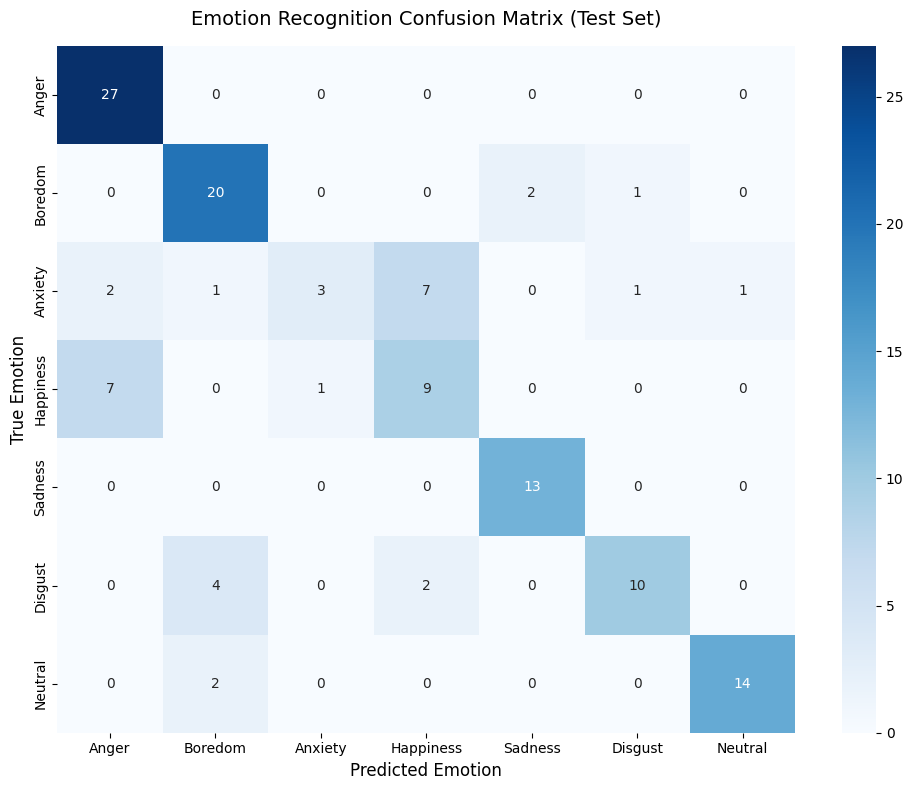

In [33]:
# ==========================================
# 4. SVM CLASSIFICATION
# ==========================================

print("\nTraining Linear SVM on DTPM features...")
# Using Linear Kernel and One-vs-One strategy [cite: 413, 426]
svm_classifier = SVC(kernel='linear', decision_function_shape='ovo')
svm_classifier.fit(X_train_scaled, y_train_global)

print("Evaluating on unseen Test Set (Speakers 15 & 16)...")
predictions = svm_classifier.predict(X_test_scaled)

report = classification_report(y_test_global, predictions)

accuracy = accuracy_score(y_test_global, predictions)
print("\n--- Final Utterance-Level Results ---")
print(f"Accuracy (Weighted Average Recall): {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(report)

joblib.dump(svm_classifier, os.path.join(model_dir, svm_name))
print("Complete model successfully trained and saved!")

# save the results of classification report to a text file

with open(os.path.join(results_dir, f"classification_report_{dataset.split('/')[-1]}.txt"), "w") as f:
    f.write(f"Accuracy (Weighted Average Recall): {accuracy * 100:.2f}%\n\n")
    f.write(report)


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the actual string names for EMO-DB in order (0 to 6)
# Map: 0=Anger(W), 1=Boredom(L), 2=Anxiety(A), 3=Happiness(F), 4=Sadness(T), 5=Disgust(E), 6=Neutral(N)
EMOTION_NAMES = ['Anger', 'Boredom', 'Anxiety', 'Happiness', 'Sadness', 'Disgust', 'Neutral']

# 2. Calculate the confusion matrix
cm = confusion_matrix(y_test_global, predictions)

# 3. Set up the plot aesthetics
plt.figure(figsize=(10, 8)) # Slightly larger for better text readability
sns.heatmap(cm, 
            annot=True,       # Show the numbers inside the boxes
            fmt='d',          # Format as whole integers (no decimals)
            cmap='Blues',     # Use a clean blue color gradient
            xticklabels=EMOTION_NAMES, 
            yticklabels=EMOTION_NAMES)

# 4. Add labels and title
plt.title('Emotion Recognition Confusion Matrix (Test Set)', fontsize=14, pad=15)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)

# Ensure labels don't get cut off when saving
plt.tight_layout() 

# 5. Save the plot to a file BEFORE calling plt.show()
# dpi=300 ensures it is saved in high resolution (great for presentations/reports)
plt.savefig(os.path.join(results_dir, f'confusion_matrix_{dataset.split("/")[-1]}.png'), dpi=300, bbox_inches='tight')

# 6. Display it in your Jupyter Notebook
plt.show()